In [169]:
import kagglehub
import shutil
import os
import pandas as pd
import csv
import numpy as np

import random
random.seed(42)
np.random.seed(42)

# Download to cache
#cache_path = kagglehub.dataset_download("sharmajicoder/gaming-and-mental-health")
cache_path = kagglehub.dataset_download("imadkhattak/airbnb-data")

# Define your repo data folder
repo_data_path = "./data"

# Create folder if it doesn't exist
os.makedirs(repo_data_path, exist_ok=True)

# Copy files from cache to repo
for file_name in os.listdir(cache_path):
    shutil.copy(os.path.join(cache_path, file_name), repo_data_path)

print("Dataset copied to:", repo_data_path)

Dataset copied to: ./data


In [170]:
import pandas as pd
# Load the CSV file into a DataFrame
df = pd.read_csv("./data/train_regression.csv")
# Display the first few rows of the DataFrame
df.head(10)

,id,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,5.387292e+07,366516391,4/9/2018,"Chicago, IL",within an hour,96%,95%,f,Back of the Yards,11,...,5.00,5.00,4.28,4.83,f,9,1,8,0,0.33
1,3.926966e+07,50276775,12/23/2014,NaN,within an hour,100%,97%,f,Clearwater Beach,1141,...,NaN,NaN,NaN,NaN,t,58,0,58,0,NaN
2,5.564810e+17,681680651,3/8/2020,NaN,within an hour,100%,100%,f,Lake View East,1,...,5.00,5.00,4.93,4.80,f,1,1,0,0,2.78
3,5.239728e+07,94345291,10/22/2015,"Chicago, IL",within an hour,100%,98%,f,Bucktown,55,...,4.38,4.23,4.54,3.85,t,55,55,0,0,3.61
4,7.459490e+17,790998106,4/4/2021,"Chicago, IL",within an hour,100%,100%,t,Near South Side,74,...,4.83,4.85,4.74,4.72,t,74,74,0,0,3.24
5,7.407770e+17,50276775,12/23/2014,NaN,within an hour,100%,97%,f,Clearwater Beach,1141,...,5.00,5.00,4.00,5.00,t,58,0,58,0,1.18
6,8.416530e+17,570167059,8/12/2019,"Chicago, IL",within a few hours,100%,97%,t,Hyde Park,3,...,4.69,4.86,4.43,4.63,f,3,3,0,0,0.88
7,7.645760e+17,975964114,11/16/2022,NaN,within an hour,100%,99%,t,Humboldt Park,4,...,4.84,4.92,4.40,4.72,f,4,4,0,0,2.43
8,8.564280e+17,44110882,10/2/2014,"Chicago, IL",within a few hours,100%,93%,f,Douglas,1,...,4.88,4.94,4.78,4.91,f,1,1,0,0,1.92
9,8.624450e+17,497520971,3/14/2019,NaN,within an hour,99%,99%,t,West Loop/Greektown,71,...,4.85,5.00,5.00,4.69,t,51,51,0,0,1.38


In [171]:
train = pd.read_csv("./data/train_regression.csv")
test = pd.read_csv("./data/test_regression.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (5000, 54)
Test shape: (3338, 53)


In [172]:
missing_df = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percent": df.isna().mean() * 100
}).sort_values("Missing_Percent", ascending=False)

missing_df

,Missing_Count,Missing_Percent
reviews_per_month,1042,20.84
review_scores_cleanliness,1042,20.84
first_review,1042,20.84
last_review,1042,20.84
review_scores_communication,1042,20.84
review_scores_accuracy,1041,20.82
review_scores_value,1041,20.82
review_scores_rating,1041,20.82
review_scores_checkin,1041,20.82
review_scores_location,1041,20.82


In [173]:
missing_df = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percent": df.isna().mean() * 100
}).sort_index()

missing_df

,Missing_Count,Missing_Percent
accommodates,0,0.00
availability_30,0,0.00
availability_365,0,0.00
availability_60,0,0.00
availability_90,0,0.00
bathrooms_text,4,0.08
beds,48,0.96
calculated_host_listings_count,0,0.00
calculated_host_listings_count_entire_homes,0,0.00
calculated_host_listings_count_private_rooms,0,0.00


# GUIDE SETUP

In [174]:
original_cols_to_keep = [
    'host_response_rate',
    'host_acceptance_rate',
    'host_is_superhost',
    'accommodates',
    'bathrooms_text',
    'beds',
    'price',
    'minimum_nights',
    'maximum_nights',
    'has_availability',
    'number_of_reviews',
    'review_scores_rating',
    'instant_bookable',
    'reviews_per_month'
]

clean_df = df[original_cols_to_keep].copy()

# modify bathrooms_text to extract numeric value
clean_df["bathrooms"] = (
    clean_df["bathrooms_text"]
    .str.extract(r"(\d+\.?\d*)")
    .astype(float)
)

# PRICE: Remove $, commas, spaces
clean_df["price"] = (
    clean_df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)

# RATES: Remove % and convert to float
clean_df["host_acceptance_rate"] = (
    clean_df["host_acceptance_rate"]
    .str.replace("%", "", regex=False)
    .astype(float)
    / 100
)
clean_df["host_response_rate"] = (
    clean_df["host_response_rate"]
    .str.replace("%", "", regex=False)
    .astype(float)
    / 100
)

clean_df["price"] = np.log(clean_df["price"])

# drop certain columns
cols_to_remove = [
    "bathrooms_text"
]

clean_df = clean_df.drop(columns=cols_to_remove)

clean_df.head()


,host_response_rate,host_acceptance_rate,host_is_superhost,accommodates,beds,price,minimum_nights,maximum_nights,has_availability,number_of_reviews,review_scores_rating,instant_bookable,reviews_per_month,bathrooms
0,0.96,0.95,f,1,1.0,3.401197,32,1125,t,18,4.94,f,0.33,1.0
1,1.00,0.97,f,12,3.0,7.128496,32,365,t,0,NaN,t,NaN,3.0
2,1.00,1.00,f,6,3.0,5.365976,2,45,t,14,4.87,f,2.78,1.0
3,1.00,0.98,f,2,1.0,4.077537,2,180,t,13,4.08,t,3.61,1.0
4,1.00,1.00,t,6,3.0,5.017280,2,365,t,64,4.80,t,3.24,2.0


In [175]:
# airbnb.dsc

# SETTINGS
dsc_filename = "airbnb.dsc"
data_filename = "airbnb.txt"
missing_value = "NA"

# Class
class_count = 2

# WRITE DATA FILE
setup_df = clean_df.fillna(missing_value)

setup_df.to_csv(
    data_filename,
    sep=" ",
    index=False,
    header=True
)

# DETERMINE VARIABLE TYPES
lines = []
target_column = "price"

for i, col in enumerate(clean_df.columns, start=1):
    if col == target_column:
        # Dependent variable or death indicator variable. TARGET
        var_type = "d"
    elif pd.api.types.is_numeric_dtype(clean_df[col]):
        # Numerical variable used both for splitting the nodes and for fitting 
        # the node regression models
        var_type = "n"
    else:
        # Categorical variable used both for splitting and for node modeling in regression
        var_type = "b"
    lines.append(f"{i} {col} {var_type}")

# WRITE DSC FILE
with open(dsc_filename, "w") as f:
    f.write(f"{data_filename}\n")
    f.write(f"{missing_value}\n")
    f.write(f"{class_count}\n")
    for line in lines:
        f.write(line + "\n")

print("DSC file created successfully.")


DSC file created successfully.


In [176]:
setup_df

,host_response_rate,host_acceptance_rate,host_is_superhost,accommodates,beds,price,minimum_nights,maximum_nights,has_availability,number_of_reviews,review_scores_rating,instant_bookable,reviews_per_month,bathrooms
0,0.96,0.95,f,1,1.0,3.401197,32,1125,t,18,4.94,f,0.33,1.0
1,1.0,0.97,f,12,3.0,7.128496,32,365,t,0,NA,t,NA,3.0
2,1.0,1.0,f,6,3.0,5.365976,2,45,t,14,4.87,f,2.78,1.0
3,1.0,0.98,f,2,1.0,4.077537,2,180,t,13,4.08,t,3.61,1.0
4,1.0,1.0,t,6,3.0,5.017280,2,365,t,64,4.8,t,3.24,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.88,0.84,t,2,1.0,4.510860,3,90,t,79,4.98,f,1.32,1.0
4996,1.0,0.89,t,2,1.0,3.828641,1,90,t,59,4.71,f,13.11,1.0
4997,1.0,0.97,f,4,2.0,4.605170,3,180,t,36,4.94,f,0.7,1.0
4998,1.0,0.97,f,4,2.0,5.129899,32,1125,t,0,NA,f,NA,1.0


In [177]:
setup_df.columns.tolist()

['host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'accommodates',
 'beds',
 'price',
 'minimum_nights',
 'maximum_nights',
 'has_availability',
 'number_of_reviews',
 'review_scores_rating',
 'instant_bookable',
 'reviews_per_month',
 'bathrooms']

# PYTHON WORK

In [178]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

In [179]:
df = setup_df.copy()

bool_cols = ["host_is_superhost", "has_availability", "instant_bookable"]

for c in bool_cols:
    df[c] = df[c].map({"t":1, "f":0})

df = df.replace("NA", np.nan)
df

,host_response_rate,host_acceptance_rate,host_is_superhost,accommodates,beds,price,minimum_nights,maximum_nights,has_availability,number_of_reviews,review_scores_rating,instant_bookable,reviews_per_month,bathrooms
0,0.96,0.95,0.0,1,1.0,3.401197,32,1125,1,18,4.94,0,0.33,1.0
1,1.00,0.97,0.0,12,3.0,7.128496,32,365,1,0,NaN,1,NaN,3.0
2,1.00,1.00,0.0,6,3.0,5.365976,2,45,1,14,4.87,0,2.78,1.0
3,1.00,0.98,0.0,2,1.0,4.077537,2,180,1,13,4.08,1,3.61,1.0
4,1.00,1.00,1.0,6,3.0,5.017280,2,365,1,64,4.80,1,3.24,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.88,0.84,1.0,2,1.0,4.510860,3,90,1,79,4.98,0,1.32,1.0
4996,1.00,0.89,1.0,2,1.0,3.828641,1,90,1,59,4.71,0,13.11,1.0
4997,1.00,0.97,0.0,4,2.0,4.605170,3,180,1,36,4.94,0,0.70,1.0
4998,1.00,0.97,0.0,4,2.0,5.129899,32,1125,1,0,NaN,0,NaN,1.0


## Dropped NaN

In [180]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# FIX DF FOR PYTHON
df = setup_df.copy()

# convert "NA" strings to real missing values
df = df.replace("NA", np.nan)

# convert boolean columns
bool_cols = ["host_is_superhost", "has_availability", "instant_bookable"]
for c in bool_cols:
    df[c] = df[c].map({"t": 1, "f": 0})

# remove rows with missing values
df = df.dropna()


# SPLIT PREDICTORS AND RESPONSE

X = df.drop(columns=["price"])
y = df["price"]


# TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# DEC TREE

tree = DecisionTreeRegressor(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

print("Decision Tree R2:", tree.score(X_test, y_test))


# RANDOM FOREST

rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

print("Random Forest R2:", rf.score(X_test, y_test))


# CALC IMPORTANT

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("\nRandom Forest Feature Importance:")
print(importance)

Decision Tree R2: 0.5300244640603387
Random Forest R2: 0.6471505997751988

Random Forest Feature Importance:
accommodates            0.421118
bathrooms               0.153384
reviews_per_month       0.102850
review_scores_rating    0.074097
number_of_reviews       0.059161
host_acceptance_rate    0.055845
maximum_nights          0.040621
minimum_nights          0.031207
host_response_rate      0.022798
beds                    0.020652
host_is_superhost       0.009283
instant_bookable        0.008984
has_availability        0.000000
dtype: float64


In [181]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf, X, y, cv=10, scoring="r2")
print("Random Forest CV R2:", scores.mean())

Random Forest CV R2: 0.6620934344588584


                Variable     Score  Normalized
0           accommodates  0.421118  100.000000
1              bathrooms  0.153384   36.422979
2      reviews_per_month  0.102850   24.423153
3   review_scores_rating  0.074097   17.595255
4      number_of_reviews  0.059161   14.048618
5   host_acceptance_rate  0.055845   13.261007
6         maximum_nights  0.040621    9.646022
7         minimum_nights  0.031207    7.410516
8     host_response_rate  0.022798    5.413606
9                   beds  0.020652    4.904148
10     host_is_superhost  0.009283    2.204327
11      instant_bookable  0.008984    2.133422
12      has_availability  0.000000    0.000000


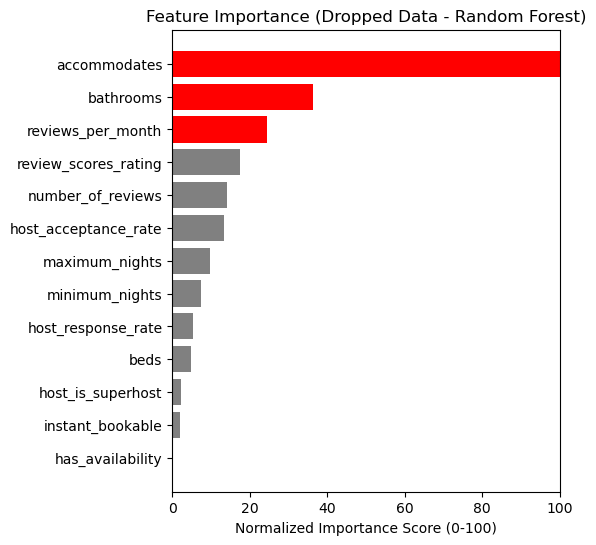

In [182]:
import matplotlib.pyplot as plt

importance_df = importance.reset_index()
importance_df.columns = ["Variable", "Score"]
importance_df = importance_df.sort_values("Score", ascending=True)
importance_df["Normalized"] = (importance_df["Score"] / importance_df["Score"].max()) * 100
print(importance_df[["Variable", "Score", "Normalized"]].sort_values("Score", ascending=False))


threshold = 0.2 * importance_df["Normalized"].max()  # 20% of max
colors = ["red" if s >= threshold else "gray" for s in importance_df["Normalized"]]

top_k = 3
colors = ["red" if i >= len(importance_df) - top_k else "gray"
          for i in range(len(importance_df))]

plt.figure(figsize=(5, 6))
plt.barh(importance_df["Variable"], importance_df["Normalized"], color=colors)
plt.xlabel("Normalized Importance Score (0-100)")
plt.title("Feature Importance (Dropped Data - Random Forest)")
#plt.axvline(threshold, linestyle="--", color="darkred", label=f"Threshold = {threshold}")
plt.savefig("rf_dropped_feature_importance.png", dpi=300, bbox_inches="tight")
plt.xlim(0, 100)
plt.show()


In [183]:
from sklearn.linear_model import LinearRegression

# LINEAR REGRESSION
lr = LinearRegression()
lr.fit(X_train, y_train)

print("Linear Regression R2:", lr.score(X_test, y_test))

# Coefficients — interpretable since response is log(price)
coef = pd.Series(lr.coef_, index=X.columns).sort_values(ascending=False)
print("\nLinear Regression Coefficients:")
print(coef)

Linear Regression R2: 0.45099980210765966

Linear Regression Coefficients:
bathrooms               1.514201e-01
review_scores_rating    1.490448e-01
accommodates            1.340713e-01
host_is_superhost       8.830346e-02
host_response_rate      1.826685e-03
maximum_nights          1.407595e-04
has_availability       -3.053113e-16
number_of_reviews      -2.043512e-05
minimum_nights         -3.777106e-04
beds                   -7.445768e-03
instant_bookable       -1.175828e-02
reviews_per_month      -2.058149e-02
host_acceptance_rate   -4.849520e-02
dtype: float64


In [184]:
importance_df["Normalized"] = (importance_df["Score"] / importance_df["Score"].max()) * 100
print(importance_df[["Variable", "Score", "Normalized"]].sort_values("Score", ascending=False))


                Variable     Score  Normalized
0           accommodates  0.421118  100.000000
1              bathrooms  0.153384   36.422979
2      reviews_per_month  0.102850   24.423153
3   review_scores_rating  0.074097   17.595255
4      number_of_reviews  0.059161   14.048618
5   host_acceptance_rate  0.055845   13.261007
6         maximum_nights  0.040621    9.646022
7         minimum_nights  0.031207    7.410516
8     host_response_rate  0.022798    5.413606
9                   beds  0.020652    4.904148
10     host_is_superhost  0.009283    2.204327
11      instant_bookable  0.008984    2.133422
12      has_availability  0.000000    0.000000


# Imputed NaNs

In [185]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer


# FIX DF FOR PYTHON

df = setup_df.copy()

# convert "NA" strings to real missing values
df = df.replace("NA", np.nan)

# convert boolean columns
bool_cols = ["host_is_superhost", "has_availability", "instant_bookable"]
for c in bool_cols:
    df[c] = df[c].map({"t": 1, "f": 0})


# SPLIT PREDICTORS AND RESPONSE

X = df.drop(columns=["price"])
y = df["price"]


# TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# IMPUTATION (fit ONLY on training data)

imputer = SimpleImputer(strategy="mean")

X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns)


# DECISION TREE

tree = DecisionTreeRegressor(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

print("Decision Tree R2:", tree.score(X_test, y_test))


# RANDOM FOREST

rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

print("Random Forest R2:", rf.score(X_test, y_test))


# CALC FEATURE IMPORTANCE

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("\nRandom Forest Feature Importance:")
print(importance)

Decision Tree R2: 0.48909648928989946
Random Forest R2: 0.6377011771550265

Random Forest Feature Importance:
accommodates            0.370477
bathrooms               0.152952
reviews_per_month       0.077939
number_of_reviews       0.071233
host_acceptance_rate    0.070309
review_scores_rating    0.064909
maximum_nights          0.064162
minimum_nights          0.041534
host_response_rate      0.036070
beds                    0.025377
instant_bookable        0.012944
host_is_superhost       0.010669
has_availability        0.001426
dtype: float64


In [186]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf, X, y, cv=10, scoring="r2")
print("Random Forest CV R2:", scores.mean())

Random Forest CV R2: nan


/Users/hungrydoor14/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:372: FitFailedWarning: 
10 fits failed out of a total of 10.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/hungrydoor14/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/hungrydoor14/opt/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_forest.py", line 327, in fit
    X, y = self._validate_data(
  File "/Users/hungrydoor14/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py", line 581, in _validate_data
    X, 

                Variable     Score  Normalized
0           accommodates  0.370477  100.000000
1              bathrooms  0.152952   41.285136
2      reviews_per_month  0.077939   21.037489
3      number_of_reviews  0.071233   19.227304
4   host_acceptance_rate  0.070309   18.977817
5   review_scores_rating  0.064909   17.520294
6         maximum_nights  0.064162   17.318675
7         minimum_nights  0.041534   11.211010
8     host_response_rate  0.036070    9.735979
9                   beds  0.025377    6.849897
10      instant_bookable  0.012944    3.493972
11     host_is_superhost  0.010669    2.879686
12      has_availability  0.001426    0.384809


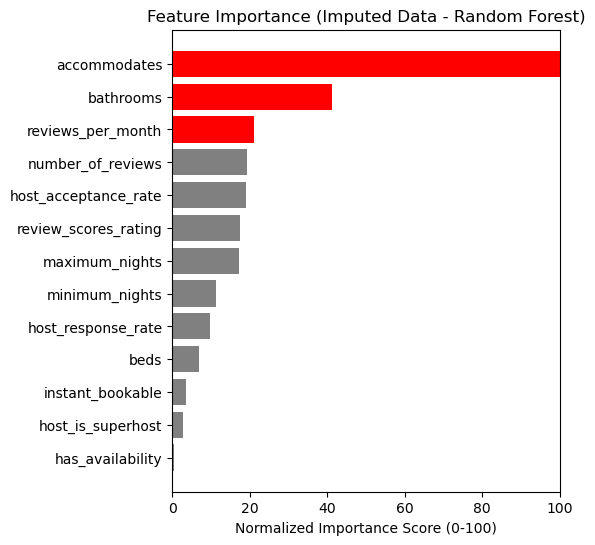

In [187]:
import matplotlib.pyplot as plt

importance_df = importance.reset_index()
importance_df.columns = ["Variable", "Score"]
importance_df = importance_df.sort_values("Score", ascending=True)

importance_df["Normalized"] = (importance_df["Score"] / importance_df["Score"].max()) * 100
print(importance_df[["Variable", "Score", "Normalized"]].sort_values("Score", ascending=False))


threshold = 0.2 * importance_df["Normalized"].max()  # 20% of max
colors = ["red" if s >= threshold else "gray" for s in importance_df["Normalized"]]

top_k = 3
colors = ["red" if i >= len(importance_df) - top_k else "gray"
          for i in range(len(importance_df))]

plt.figure(figsize=(5, 6))
plt.barh(importance_df["Variable"], importance_df["Normalized"], color=colors)
plt.xlabel("Normalized Importance Score (0-100)")
plt.title("Feature Importance (Imputed Data - Random Forest)")
#plt.axvline(threshold, linestyle="--", color="darkred", label=f"Threshold = {threshold}")
plt.savefig("rf_imputed_feature_importance.png", dpi=300, bbox_inches="tight")
plt.xlim(0, 100)
plt.show()


# Data visualization

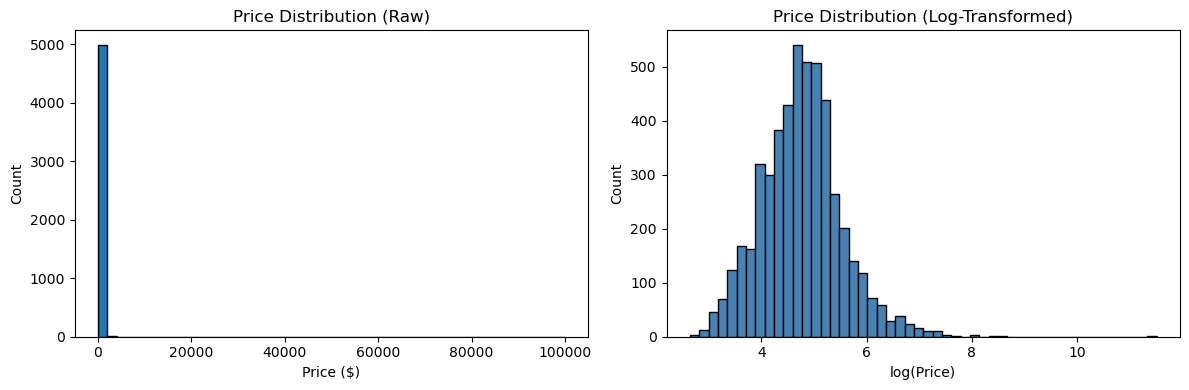

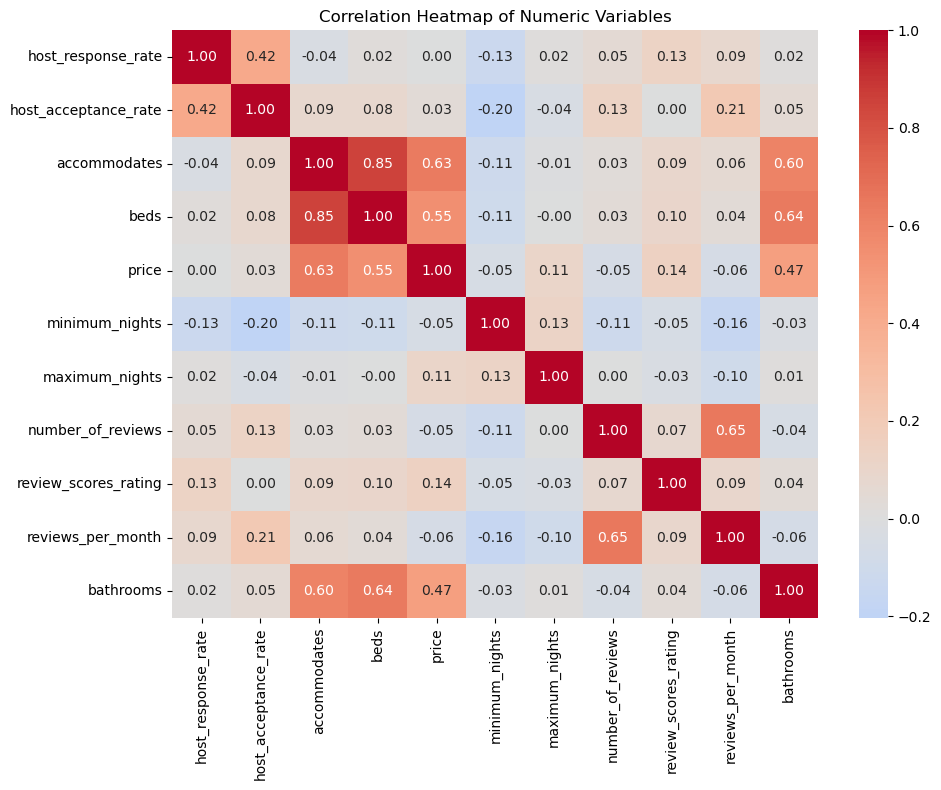

In [188]:
import matplotlib.pyplot as plt
import seaborn as sns

# PRICE DISTRIBUTION
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(np.exp(clean_df["price"]), bins=50, edgecolor="black")
axes[0].set_title("Price Distribution (Raw)")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Count")

axes[1].hist(clean_df["price"], bins=50, edgecolor="black", color="steelblue")
axes[1].set_title("Price Distribution (Log-Transformed)")
axes[1].set_xlabel("log(Price)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("price_distribution.png", dpi=150)
plt.show()

# CORRELATION HEATMAP
numeric_df = clean_df.select_dtypes(include="number")

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

In [189]:
print(clean_df["price"].describe())
print("\nTop 10 most expensive listings:")
print(np.exp(clean_df["price"]).sort_values(ascending=False).head(10))

count    5000.000000
mean        4.756854
std         0.768302
min         2.639057
25%         4.262680
50%         4.744932
75%         5.187386
max        11.512905
Name: price, dtype: float64

Top 10 most expensive listings:
3129    99998.0
523      5000.0
1626     4500.0
1823     3319.0
2327     3000.0
2266     3000.0
118      2249.0
1662     2218.0
1813     1999.0
301      1964.0
Name: price, dtype: float64


In [190]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf, X, y, cv=10, scoring="r2")
print("Random Forest CV R2:", scores.mean())

Random Forest CV R2: nan


/Users/hungrydoor14/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:372: FitFailedWarning: 
10 fits failed out of a total of 10.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/hungrydoor14/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/hungrydoor14/opt/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_forest.py", line 327, in fit
    X, y = self._validate_data(
  File "/Users/hungrydoor14/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py", line 581, in _validate_data
    X, 

In [191]:
scores

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])

In [192]:
from sklearn.model_selection import cross_val_score

scores_lr = cross_val_score(lr, X, y, cv=10, scoring="r2")
print("Linear Regression CV R2:", scores_lr.mean())

Linear Regression CV R2: nan


/Users/hungrydoor14/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:372: FitFailedWarning: 
10 fits failed out of a total of 10.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/hungrydoor14/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/hungrydoor14/opt/anaconda3/lib/python3.9/site-packages/sklearn/linear_model/_base.py", line 662, in fit
    X, y = self._validate_data(
  File "/Users/hungrydoor14/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py", line 581, in _validate_data
    X

# GUIDE Importance reading

In [193]:
# GUIDE txt file manipulation
import pandas as pd

# Read the file (fixed-width format)
df = pd.read_fwf("importance.txt")

# Convert Score from scientific notation to float (just in case)
df["Score"] = df["Score"].astype(float)

# Check result
df.head()

,Rank,Group,Score,Missing,Variable
0,1,A,106.60,0,accommodates
1,2,A,68.16,48,beds
2,3,A,64.72,11,bathrooms
3,4,A,24.53,1041,review_scores_rating
4,5,A,16.35,0,maximum_nights


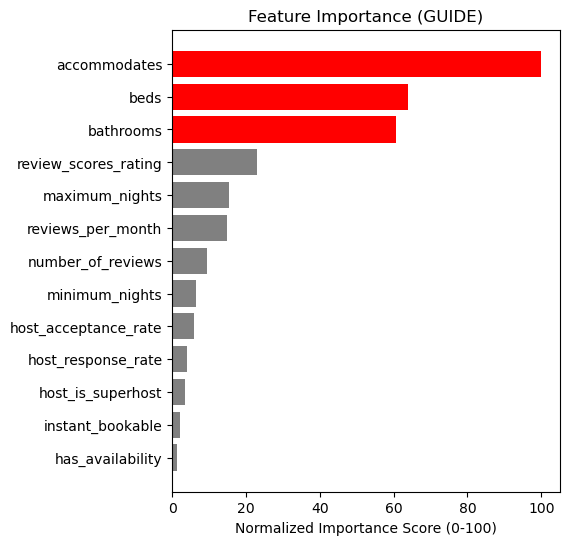

In [194]:
import matplotlib.pyplot as plt

df_sorted = df.copy()
df_sorted["Score"] = (df_sorted["Score"] / df_sorted["Score"].max()) * 100
df_sorted = df_sorted.sort_values(by="Score", ascending=True)

threshold = 20
colors = ["red" if score >= threshold else "gray" for score in df_sorted["Score"]]
top_k = 3
colors = ["red" if i >= len(importance_df) - top_k else "gray"
          for i in range(len(importance_df))]

plt.figure(figsize=(5, 6))
plt.barh(df_sorted["Variable"], df_sorted["Score"], color=colors)
plt.xlabel("Normalized Importance Score (0-100)")
plt.title("Feature Importance (GUIDE)")
#plt.axvline(threshold, linestyle="--", color="darkred", label=f"Threshold = {threshold}")
plt.savefig("guide_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [195]:
df["Normalized"] = (df["Score"] / df["Score"].max()) * 100
print(df)

    Rank Group    Score  Missing              Variable  Normalized
0      1     A  106.600        0          accommodates  100.000000
1      2     A   68.160       48                  beds   63.939962
2      3     A   64.720       11             bathrooms   60.712946
3      4     A   24.530     1041  review_scores_rating   23.011257
4      5     A   16.350        0        maximum_nights   15.337711
5      6     A   15.780     1042     reviews_per_month   14.803002
6      7     A   10.120        0     number_of_reviews    9.493433
7      8     A    6.899        0        minimum_nights    6.471857
8      9     A    6.252      291  host_acceptance_rate    5.864916
9     10     A    4.243      418    host_response_rate    3.980300
10    11     A    3.819       23     host_is_superhost    3.582552
11    12     A    2.224        0      instant_bookable    2.086304
12    13     A    1.470        0      has_availability    1.378987
